## Introduction to Rainfields 

Rainfields 3 is a comprehensive framework providing real-time quality control for operational weather radar networks.  The system currently services the entire Australian Weather Radar Network comprising of over 70 weather radars.

Rainfields offers a large array of weather radar derived and related products in near real time. 

https://thredds.nci.org.au/thredds/catalog/rq0/rainfields3/catalog.html

## More details about Rainfields

# Ground Reflectivity data

In [5]:
import os
import xarray as xr
import requests
import zipfile
import matplotlib.pyplot as plt

In [29]:
### Helper function to download and extract zip file from Threads

def download_file(url, local_filename):
    print(f"Downloading {url}...")
    response = requests.get(url, stream=True)
    response.raise_for_status()
    with open(local_filename, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Successfully downloaded {local_filename}")
    return local_filename

def extract_zip(zip_file, extract_dir):
    print(f"Extracting {zip_file} to {extract_dir}...")
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction completed")
    return extract_dir

In [31]:
zip_file_url = "https://thredds.nci.org.au/thredds/fileServer/rq0/rainfields3/2/2024/gndrefl/2_20240101.gndrefl.zip"
local_zip_filename = "2_20240101.gndrefl.zip"
extracted_dir = "./extracted_data"

In [32]:
download_file(zip_file_url,local_zip_filename)
extract_zip(local_zip_filename,extracted_dir)

Successfully downloaded 2_20240101.gndrefl.zip
Extracting 2_20240101.gndrefl.zip to ./extracted_data...
Extraction completed


'./extracted_data'

In [41]:
! ls ./extracted_data/*2*.gndrefl*.nc

./extracted_data/2_20240101_000000.gndrefl.nc
./extracted_data/2_20240101_000500.gndrefl.nc
./extracted_data/2_20240101_001000.gndrefl.nc
./extracted_data/2_20240101_001500.gndrefl.nc
./extracted_data/2_20240101_002000.gndrefl.nc
./extracted_data/2_20240101_002500.gndrefl.nc
./extracted_data/2_20240101_003000.gndrefl.nc
./extracted_data/2_20240101_003500.gndrefl.nc
./extracted_data/2_20240101_004000.gndrefl.nc
./extracted_data/2_20240101_004500.gndrefl.nc
./extracted_data/2_20240101_005000.gndrefl.nc
./extracted_data/2_20240101_005500.gndrefl.nc
./extracted_data/2_20240101_010000.gndrefl.nc
./extracted_data/2_20240101_010500.gndrefl.nc
./extracted_data/2_20240101_011000.gndrefl.nc
./extracted_data/2_20240101_011500.gndrefl.nc
./extracted_data/2_20240101_012000.gndrefl.nc
./extracted_data/2_20240101_012500.gndrefl.nc
./extracted_data/2_20240101_013000.gndrefl.nc
./extracted_data/2_20240101_013500.gndrefl.nc
./extracted_data/2_20240101_014000.gndrefl.nc
./extracted_data/2_20240101_014500

In [42]:
## Reading ground reflectivity file
da = xr.open_dataset('./extracted_data/2_20240101_125000.gndrefl.nc')

In [34]:
da

<xarray.Dataset>
Dimensions:           (y: 512, n2: 2, x: 512)
Coordinates:
  * y                 (y) float64 127.8 127.2 126.8 ... -126.8 -127.2 -127.8
  * x                 (x) float64 -127.8 -127.2 -126.8 ... 126.8 127.2 127.8
Dimensions without coordinates: n2
Data variables:
    valid_time        datetime64[ns] ...
    proj              int8 ...
    y_bounds          (y, n2) float64 ...
    x_bounds          (x, n2) float64 ...
    reflectivity      (y, x) float32 ...
    error             (y, x) float32 ...
    doppler_velocity  (y, x) float32 ...
Attributes:
    Conventions:   CF-1.7
    title:         Corrected Reflectivity at Ground
    institution:   Commonwealth of Australia, Bureau of Meteorology (ABN 92 6...
    licence:       http://www.bom.gov.au/other/copyright.shtml
    source:        rainfields 3.3.0 2023-11-21
    station_id:    2
    station_name:  Melb

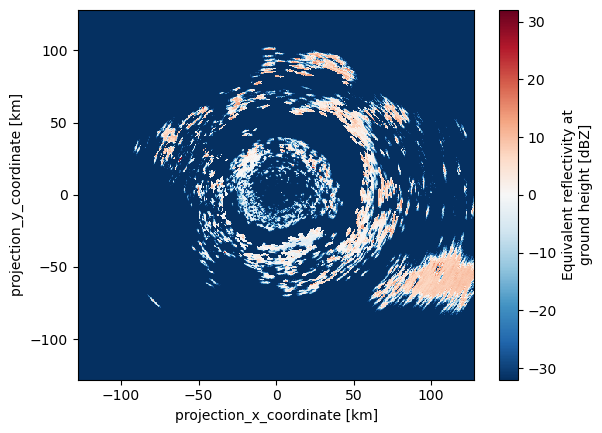

In [35]:
da.reflectivity.plot()

### Converting Reflectivity into raw rain rate

Z-R relationship

The relationship between rainfall and reflectivity is expressed as a power-law equation, \(Z=aR^{b}\), where \(Z\) is the radar reflectivity, \(R\) is the rainfall rate, and '\(a\)' and '\(b\)' are constants that vary depending on the type of precipitation. These parameters depends mainly on the dropsize distribution of the rainfall.

For Melbourne 
a = 303.2
b = 1.66

In [36]:
MAX_DBZ = 53.0  
a_param = 303.2 
b_param = 1.66  

def reflectivity_to_rainrate(dbz, a=DEFAULT_A, b=DEFAULT_B):
    """Cap dBZ and convert to rain rate R."""
    dbz_capped = xr.where(dbz >= MAX_DBZ, MAX_DBZ, dbz)
    Z = 10 ** (dbz_capped / 10.0)
    R = (Z / a) ** (1.0 / b)
    return R


In [37]:
rain_rate = reflectivity_to_rainrate(da.reflectivity,a=a_param,b=b_param)

rain_rate.name = 'rain_rate'
rain_rate.attrs.update({
    'long_name': 'Rainfall rate',
    'units': 'mm/hr',
    'conversion': f'Z-R with a={a_param}, b={b_param}, capped at {MAX_DBZ} dBZ'
})

In [38]:
da['rain_rate'] = rain_rate

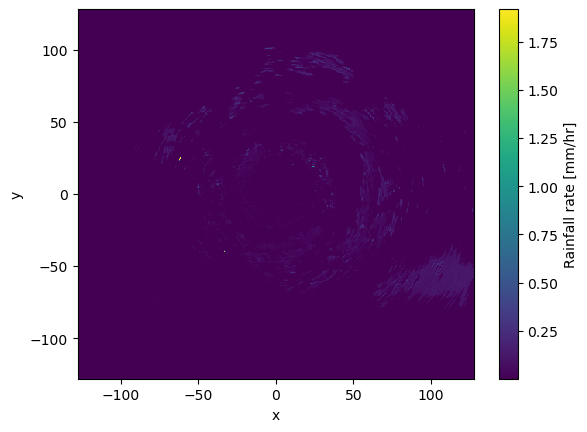

In [39]:
da.rain_rate.plot()